# Análisis Univariado: Clasificación de Artículos
En esta libreta se analiza la hoja `Clasificación_Articulos`.

Según el diccionario de datos, la columna `categoria` se construye en 3 niveles:
1. **Flujo (Nivel 1):** Digital, Análogo (técnica de elaboración de prótesis).
2. **Categoría (Nivel 2):** Consumible, Refacción, Equipo, Accesorio, Software.
3. **Subcategoría (Nivel 3):** Discos, Bloques, Fresadoras, Hornos, Dientes, etc.

### Cargar librerías y datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar la hoja 'Clasificación_Articulos'
df_articulos = pd.read_excel('Datos_CLV_2026_Tec_v2.xlsx', sheet_name='Clasificación_Articulos')

print(f"Total de registros en la hoja: {len(df_articulos):,}")
print(f"Artículos únicos catalogados: {df_articulos['articulo_id'].nunique():,}")
print(f"Total categorías únicas registradas: {df_articulos['categoria'].nunique()}")
df_articulos.head(10)

Total de registros en la hoja: 18,462
Artículos únicos catalogados: 5,431
Total categorías únicas registradas: 153


,articulo_id,nombre_articulo,categoria
0,97759,10L MAX BUILD TRAY,Digital
1,97759,10L MAX BUILD TRAY,Impresoras 3d
2,97759,10L MAX BUILD TRAY,Consumible
3,97759,10L MAX BUILD TRAY,Impresoras Dlp
4,85169,1L MAX BUILD PLASTIC TRAY FOR MAX 3D PRINTER,Digital
5,85169,1L MAX BUILD PLASTIC TRAY FOR MAX 3D PRINTER,Impresoras 3d
6,85169,1L MAX BUILD PLASTIC TRAY FOR MAX 3D PRINTER,Consumible
7,85169,1L MAX BUILD PLASTIC TRAY FOR MAX 3D PRINTER,Impresoras Dlp
8,152040,1L MAX BUILD TRAY ULTRA GLOSS,Consumible
9,152040,1L MAX BUILD TRAY ULTRA GLOSS,Digital


In [8]:
valores_nulos2=df_articulos.isnull().sum()
print('---Valores Nulos en Articulos---')

print(valores_nulos2)

---Valores Nulos en Articulos---
articulo_id        0
nombre_articulo    0
categoria          0
dtype: int64


<Figure size 1500x800 with 0 Axes>

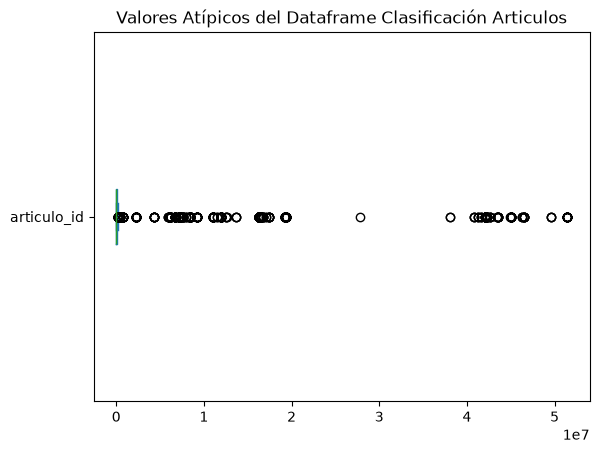

In [9]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe de compras
fig = plt.figure(figsize =(15, 8))
df_articulos.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe Clasificación Articulos")
plt.show() #dibujamos el diagrama

## 1. Análisis de Categorías Macro (Nivel 2)
Analizamos las 5 categorías macro oficiales: *Consumible, Refaccion, Equipo, Accesorio, Software*.

In [2]:
# Filtrar solo categorías oficiales de Nivel 2
macro_categorias = ['Consumible', 'Refaccion', 'Equipo', 'Accesorio', 'Software']
df_nivel2 = df_articulos[df_articulos['categoria'].isin(macro_categorias)]

# Tabla de frecuencias
tabla_cat = df_nivel2['categoria'].value_counts().reset_index()
tabla_cat.columns = ['Categoría', 'Frecuencia_Absoluta']
tabla_cat['Porcentaje (%)'] = (tabla_cat['Frecuencia_Absoluta'] / len(df_nivel2) * 100).round(2)

print("--- TABLA DE FRECUENCIAS: CATEGORÍAS MACRO (NIVEL 2) ---")
display(tabla_cat)

--- TABLA DE FRECUENCIAS: CATEGORÍAS MACRO (NIVEL 2) ---


,Categoría,Frecuencia_Absoluta,Porcentaje (%)
0,Consumible,4364,85.47
1,Refaccion,342,6.70
2,Equipo,207,4.05
3,Accesorio,123,2.41
4,Software,70,1.37


### 1.1. Gráfica de Pastel: Distribución de Categorías (Nivel 2)

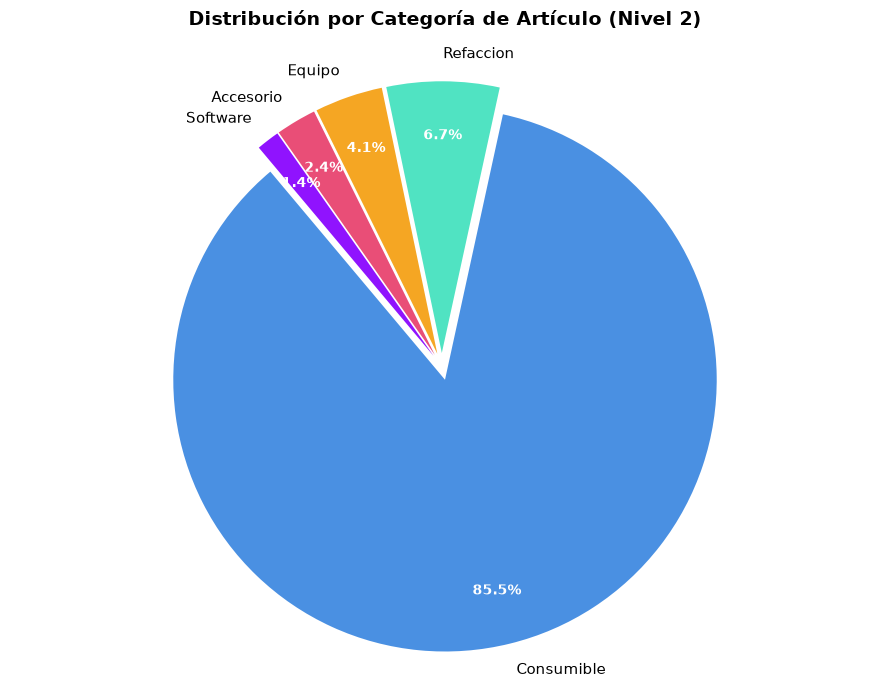

In [3]:
colores = ['#4A90E2', '#50E3C2', '#F5A623', '#E94E77', '#9013FE']
explode = [0.05, 0.05, 0.05, 0.05, 0.05]

plt.figure(figsize=(9, 7))
wedges, texts, autotexts = plt.pie(
    tabla_cat['Frecuencia_Absoluta'],
    labels=tabla_cat['Categoría'],
    autopct='%1.1f%%',
    startangle=130,
    explode=explode,
    colors=colores,
    pctdistance=0.8,
    textprops={'fontsize': 11}
)

plt.setp(autotexts, size=10, weight="bold", color="white")

plt.title('Distribución por Categoría de Artículo (Nivel 2)', fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

## 2. Análisis del Flujo de Trabajo (Nivel 1)
Compara la proporción de artículos del flujo *Digital* vs *Análogo*.

--- TABLA DE FRECUENCIAS: FLUJO (NIVEL 1) ---


,Flujo,Frecuencia_Absoluta,Porcentaje (%)
0,Analogo,4146,76.59
1,Digital,1267,23.41


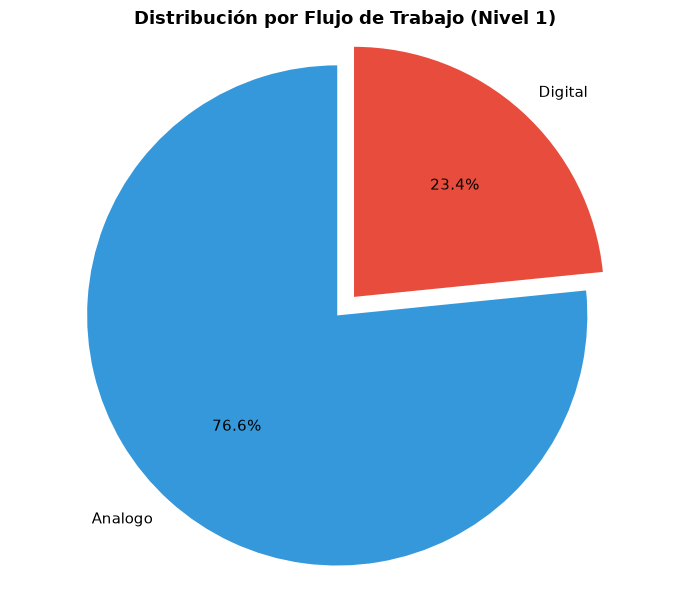

In [4]:
flujos = ['Digital', 'Analogo']
df_flujo = df_articulos[df_articulos['categoria'].isin(flujos)]

tabla_flujo = df_flujo['categoria'].value_counts().reset_index()
tabla_flujo.columns = ['Flujo', 'Frecuencia_Absoluta']
tabla_flujo['Porcentaje (%)'] = (tabla_flujo['Frecuencia_Absoluta'] / len(df_flujo) * 100).round(2)

print("--- TABLA DE FRECUENCIAS: FLUJO (NIVEL 1) ---")
display(tabla_flujo)

# Gráfica de pastel de flujo
plt.figure(figsize=(7, 6))
plt.pie(
    tabla_flujo['Frecuencia_Absoluta'],
    labels=tabla_flujo['Flujo'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#3498db', '#e74c3c'],
    explode=[0.05, 0.05],
    textprops={'fontsize': 11}
)
plt.title('Distribución por Flujo de Trabajo (Nivel 1)', fontsize=13, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

## 3. Visualización Combinada: Flujo y Categoría

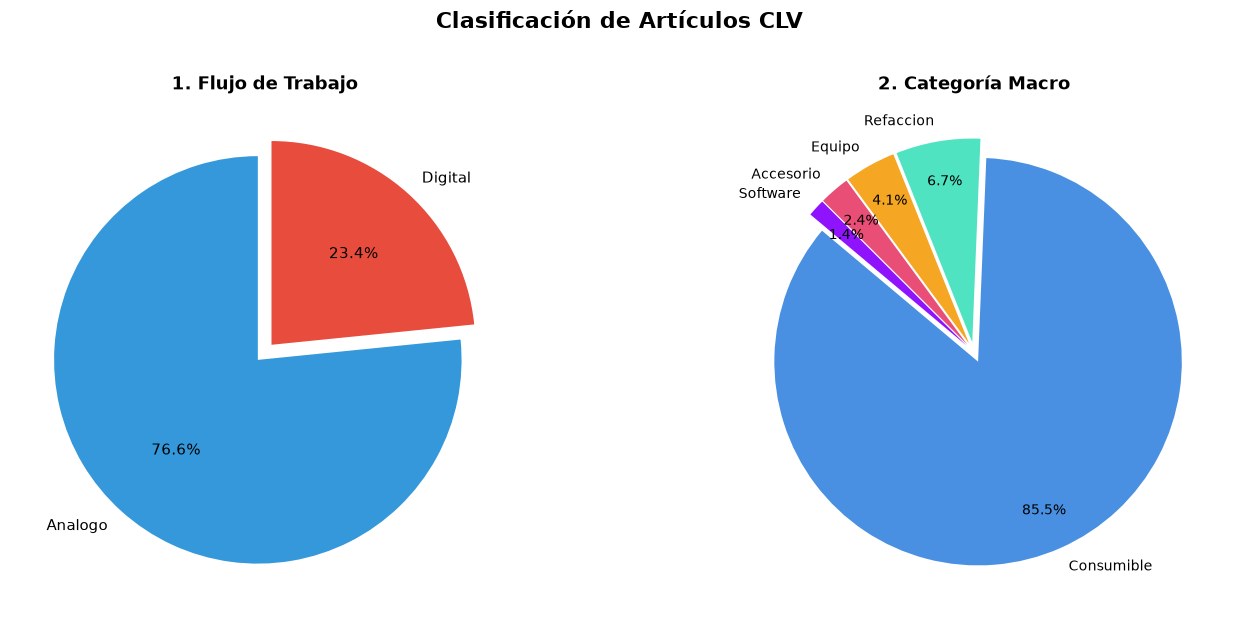

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Flujo
axes[0].pie(
    tabla_flujo['Frecuencia_Absoluta'],
    labels=tabla_flujo['Flujo'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#3498db', '#e74c3c'],
    explode=[0.05, 0.05],
    textprops={'fontsize': 11}
)
axes[0].set_title('1. Flujo de Trabajo', fontsize=13, fontweight='bold')

# Subplot 2: Categoría
axes[1].pie(
    tabla_cat['Frecuencia_Absoluta'],
    labels=tabla_cat['Categoría'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colores,
    explode=explode,
    pctdistance=0.8,
    textprops={'fontsize': 10}
)
axes[1].set_title('2. Categoría Macro', fontsize=13, fontweight='bold')

plt.suptitle('Clasificación de Artículos CLV', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Análisis de Subcategorías (Nivel 3)
Identificación de las subcategorías con mayor variedad de artículos en el catálogo.

Total de subcategorías distintas: 146

--- TOP 10 SUBCATEGORÍAS CON MÁS ARTÍCULOS ---


,Subcategoría,Frecuencia_Artículos
0,Dientes,1280
1,Ceramica De Recubrimiento,1172
2,Anterior Superior,569
3,Fresones,332
4,Discos,283
5,Posterior Inferior,237
6,Anterior Inferior,235
7,Posterior Superior,235
8,Bloques,230
9,Discos De Circonio,209


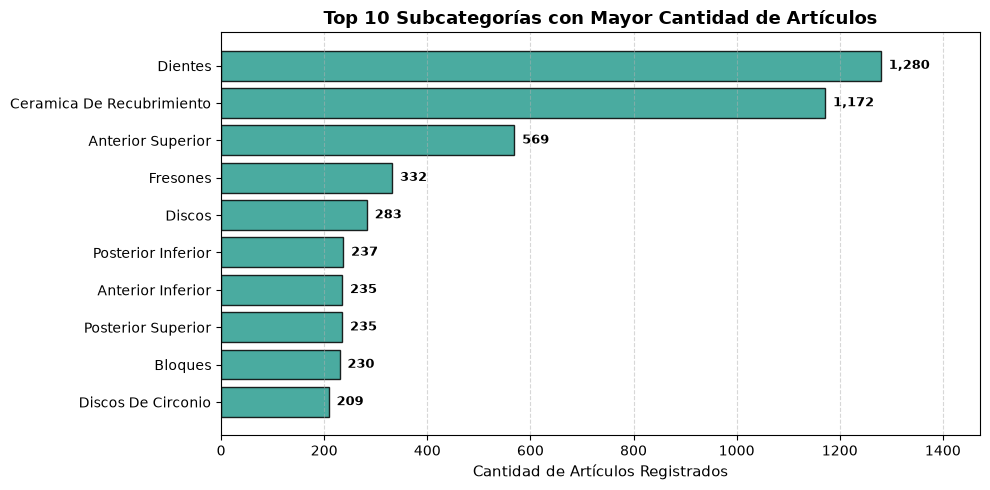

In [6]:
# Filtrar todas las categorías que no son flujo ni macro categoría
subcats = df_articulos[~df_articulos['categoria'].isin(flujos + macro_categorias)]['categoria'].value_counts()
top10_subcats = subcats.head(10).reset_index()
top10_subcats.columns = ['Subcategoría', 'Frecuencia_Artículos']

print(f"Total de subcategorías distintas: {len(subcats)}")
print("\n--- TOP 10 SUBCATEGORÍAS CON MÁS ARTÍCULOS ---")
display(top10_subcats)

# Gráfica de Barras Horizontales de Subcategorías
plt.figure(figsize=(10, 5))
barras = plt.barh(
    top10_subcats['Subcategoría'][::-1], 
    top10_subcats['Frecuencia_Artículos'][::-1], 
    color='#2a9d8f', 
    edgecolor='black', 
    alpha=0.85
)

for b in barras:
    plt.text(
        b.get_width() + 15, 
        b.get_y() + b.get_height()/2, 
        f'{int(b.get_width()):,}', 
        va='center', 
        fontsize=9, 
        fontweight='bold'
    )

plt.title('Top 10 Subcategorías con Mayor Cantidad de Artículos', fontsize=13, fontweight='bold')
plt.xlabel('Cantidad de Artículos Registrados', fontsize=11)
plt.xlim(0, top10_subcats['Frecuencia_Artículos'].max() * 1.15)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()